## Práctica adicional con Titanic

Resolver los ejercicios 7 al 16 con el DataFrame `df` cargado desde `data/titanic.csv` y las bibliotecas ya importadas (`pd`, `np` y `plt`). Cada ejercicio incluye una celda para desarrollar la solución. Cuando se agreguen columnas o completen datos, trabajar sobre una copia para conservar el dataset original.

### Ejercicio 7 — Selección y filtros combinados

1. Seleccionar las personas de tercera clase (`pclass == 3`) con edad conocida menor a 18 años.
2. Mostrar solamente `sex`, `age`, `fare` y `survived`, ordenadas por edad de menor a mayor.
3. Informar cuántas personas cumplen las condiciones y qué porcentaje representan sobre el total del dataset.

**Pista:** combinar condiciones con `&` y encerrar cada condición entre paréntesis; usar `.loc` y `.sort_values()`.

In [4]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
df.head()

filtro = (df["pclass"] == 3) & (df["age"].notna()) & (df["age"] < 18)
menores_3ra = df.loc[filtro]
resultado = (
    df.loc[filtro, ["sex", "age", "fare", "survived"]]
      .sort_values("age", ascending=True)
)
print(resultado)
cantidad = len(resultado)
porcentaje = cantidad / len(df) * 100
print(f"Personas que cumplen: {cantidad}")
print(f"Porcentaje sobre el total: {porcentaje:.2f}%")

        sex    age     fare  survived
803    male   0.42   8.5167         1
644  female   0.75  19.2583         1
469  female   0.75  19.2583         1
172  female   1.00  11.1333         1
381  female   1.00  15.7417         1
..      ...    ...      ...       ...
532    male  17.00   7.2292         0
500    male  17.00   8.6625         0
433    male  17.00   7.1250         0
114  female  17.00  14.4583         0
844    male  17.00   8.6625         0

[78 rows x 4 columns]
Personas que cumplen: 78
Porcentaje sobre el total: 8.75%


### Ejercicio 8 — Diagnóstico de valores faltantes

1. Crear una tabla con la cantidad y el porcentaje de valores nulos de cada columna.
2. Mostrar únicamente las columnas con datos faltantes, ordenadas de mayor a menor porcentaje.
3. Crear una copia de `df` y completar las edades ausentes con la mediana de `age`.
4. Comparar el promedio de edad antes y después de completar los datos. Explicar por qué podría cambiar.

**Pista:** usar `.isna()`, `.sum()`, `.copy()` y `.fillna()`. Conservar `df` sin modificar para los demás ejercicios.

In [5]:
nulos = df.isna().sum()
porcentaje = df.isna().mean() * 100

tabla_nulos = pd.DataFrame({
    "cantidad_nulos": nulos,
    "porcentaje_nulos": porcentaje.round(2)
})
print(tabla_nulos)
solo_faltantes = (
    tabla_nulos[tabla_nulos["cantidad_nulos"] > 0]
    .sort_values("porcentaje_nulos", ascending=False)
)
print(solo_faltantes)
df_copia = df.copy()
mediana_edad = df["age"].median()
df_copia["age"] = df_copia["age"].fillna(mediana_edad)
promedio_antes = df["age"].mean()
promedio_despues = df_copia["age"].mean()
print(f"Mediana usada: {mediana_edad}")
print(f"Promedio antes:   {promedio_antes:.2f}")
print(f"Promedio después: {promedio_despues:.2f}")

             cantidad_nulos  porcentaje_nulos
survived                  0              0.00
pclass                    0              0.00
sex                       0              0.00
age                     177             19.87
sibsp                     0              0.00
parch                     0              0.00
fare                      0              0.00
embarked                  2              0.22
class                     0              0.00
who                       0              0.00
adult_male                0              0.00
deck                    688             77.22
embark_town               2              0.22
alive                     0              0.00
alone                     0              0.00
             cantidad_nulos  porcentaje_nulos
deck                    688             77.22
age                     177             19.87
embarked                  2              0.22
embark_town               2              0.22
Mediana usada: 28.0
Promedio antes

### Ejercicio 9 — Tarifas y pasajeros destacados

1. Calcular el mínimo, el máximo, la media y la mediana de `fare`.
2. Mostrar las 10 filas con las tarifas más altas, incluyendo `pclass`, `sex`, `age`, `fare` y `embark_town`.
3. Contar cuántas personas tienen tarifa igual a cero.
4. Comparar la media con la mediana y explicar qué efecto podrían tener las tarifas muy altas.

**Pista:** usar `.describe()`, `.median()` y `.sort_values()` o `.nlargest()`.

In [6]:
minimo = df["fare"].min()
maximo = df["fare"].max()
media = df["fare"].mean()
mediana = df["fare"].median()

print(f"Mínimo:  {minimo:.2f}")
print(f"Máximo:  {maximo:.2f}")
print(f"Media:   {media:.2f}")
print(f"Mediana: {mediana:.2f}")

print(df["fare"].describe())

top10 = df.nlargest(10, "fare")[["pclass", "sex", "age", "fare", "embark_town"]]
print(top10)
cantidad_cero = (df["fare"] == 0).sum()
print(f"Personas con tarifa 0: {cantidad_cero}")


Mínimo:  0.00
Máximo:  512.33
Media:   32.20
Mediana: 14.45
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64
     pclass     sex   age      fare  embark_town
258       1  female  35.0  512.3292    Cherbourg
679       1    male  36.0  512.3292    Cherbourg
737       1    male  35.0  512.3292    Cherbourg
27        1    male  19.0  263.0000  Southampton
88        1  female  23.0  263.0000  Southampton
341       1  female  24.0  263.0000  Southampton
438       1    male  64.0  263.0000  Southampton
311       1  female  18.0  262.3750    Cherbourg
742       1  female  21.0  262.3750    Cherbourg
118       1    male  24.0  247.5208    Cherbourg
Personas con tarifa 0: 15


### Ejercicio 10 — Supervivencia por clase y sexo

1. Agrupar simultáneamente por `pclass` y `sex`.
2. Para cada grupo, calcular la cantidad de pasajeros, la cantidad de sobrevivientes y el porcentaje de supervivencia.
3. Ordenar los grupos por porcentaje de supervivencia e identificar el mayor y el menor.
4. Escribir una conclusión breve que tenga en cuenta también el tamaño de cada grupo.

**Pista:** usar `groupby()` con una lista de columnas y `.agg()`. En `survived`, la suma cuenta sobrevivientes y la media multiplicada por 100 expresa el porcentaje.

In [7]:
resumen = (
    df.groupby(["pclass", "sex"])
      .agg(
          pasajeros=("survived", "count"),
          sobrevivientes=("survived", "sum"),
          pct_supervivencia=("survived", lambda s: s.mean() * 100)
      )
      .round(2)
)
print(resumen)
ordenado = resumen.sort_values("pct_supervivencia", ascending=False)
print(ordenado)

print("Mayor supervivencia:", ordenado.index[0], ordenado["pct_supervivencia"].iloc[0])
print("Menor supervivencia:", ordenado.index[-1], ordenado["pct_supervivencia"].iloc[-1])

               pasajeros  sobrevivientes  pct_supervivencia
pclass sex                                                 
1      female         94              91              96.81
       male          122              45              36.89
2      female         76              70              92.11
       male          108              17              15.74
3      female        144              72              50.00
       male          347              47              13.54
               pasajeros  sobrevivientes  pct_supervivencia
pclass sex                                                 
1      female         94              91              96.81
2      female         76              70              92.11
3      female        144              72              50.00
1      male          122              45              36.89
2      male          108              17              15.74
3      male          347              47              13.54
Mayor supervivencia: (np.int64(1), 'fema

### Ejercicio 11 — Familiares a bordo

1. Crear una copia llamada `df_familias` y agregar `tamano_familia = sibsp + parch + 1`.
2. Agregar `viaja_solo`, que sea verdadero cuando el tamaño familiar sea 1.
3. Comparar `viaja_solo` con la columna `alone` e informar la cantidad de diferencias.
4. Calcular la cantidad de pasajeros y el porcentaje de supervivencia según viajen solos o acompañados.

` sibsp ` indica hermanos/as y cónyuges a bordo; `parch`, padres/madres e hijos/as. El 1 incluye al propio pasajero.

In [8]:

df_familias = df.copy()
df_familias["tamano_familia"] = df_familias["sibsp"] + df_familias["parch"] + 1

df_familias["viaja_solo"] = df_familias["tamano_familia"] == 1

diferencias = (df_familias["viaja_solo"] != df_familias["alone"]).sum()
print(f"Diferencias entre viaja_solo y alone: {diferencias}")


resumen_solo = (
    df_familias.groupby("viaja_solo")
      .agg(
          pasajeros=("survived", "count"),
          pct_supervivencia=("survived", lambda s: s.mean() * 100)
      )
      .round(2)
)
print(resumen_solo)

Diferencias entre viaja_solo y alone: 0
            pasajeros  pct_supervivencia
viaja_solo                              
False             354              50.56
True              537              30.35


### Ejercicio 12 — Función de resumen reutilizable

1. Definir `resumir_pasajeros(datos)` para recibir un DataFrame y devolver una tupla con la cantidad de pasajeros, la edad promedio y la proporción de supervivencia.
2. Si el DataFrame está vacío, devolver `(0, None, None)`. Para la edad promedio, ignorar edades ausentes; si no hay ninguna edad conocida, devolver `None` en esa posición.
3. Aplicar la función al dataset completo y luego a cada clase usando un `for`.
4. Desempaquetar los resultados y mostrarlos con etiquetas claras; expresar la supervivencia como porcentaje.
5. Probar también con `df.iloc[0:0]`.

**Pista:** usar `.empty` para comprobar si un DataFrame está vacío y `.notna().any()` para detectar si existen edades conocidas.

In [9]:
def resumir_pasajeros(datos):
 
    if datos.empty:
        return (0, None, None)

    cantidad = len(datos)

    
    if datos["age"].notna().any():
        edad_promedio = datos["age"].mean()
    else:
        edad_promedio = None


    proporcion = datos["survived"].mean()

    return (cantidad, edad_promedio, proporcion)


def mostrar_resumen(titulo, resultado):
    
    cantidad, edad, proporcion = resultado

    edad_txt = f"{edad:.2f}" if edad is not None else "sin datos"
    superv_txt = f"{proporcion * 100:.2f}%" if proporcion is not None else "sin datos"

    print(f"{titulo}")
    print(f"  Cantidad de pasajeros: {cantidad}")
    print(f"  Edad promedio:         {edad_txt}")
    print(f"  Supervivencia:         {superv_txt}")
    print()



mostrar_resumen("Dataset completo", resumir_pasajeros(df))

for clase in sorted(df["pclass"].unique()):
    subconjunto = df[df["pclass"] == clase]
    mostrar_resumen(f"Clase {clase}", resumir_pasajeros(subconjunto))


mostrar_resumen("DataFrame vacío (df.iloc[0:0])", resumir_pasajeros(df.iloc[0:0]))

Dataset completo
  Cantidad de pasajeros: 891
  Edad promedio:         29.70
  Supervivencia:         38.38%

Clase 1
  Cantidad de pasajeros: 216
  Edad promedio:         38.23
  Supervivencia:         62.96%

Clase 2
  Cantidad de pasajeros: 184
  Edad promedio:         29.88
  Supervivencia:         47.28%

Clase 3
  Cantidad de pasajeros: 491
  Edad promedio:         25.14
  Supervivencia:         24.24%

DataFrame vacío (df.iloc[0:0])
  Cantidad de pasajeros: 0
  Edad promedio:         sin datos
  Supervivencia:         sin datos



### Ejercicio 13 — Clasificación de tarifas con una función

1. Definir `clasificar_tarifa(fare)` con estas categorías: `sin dato` si es nula, `gratuita` si vale 0, `económica` si es mayor a 0 y menor a 15, `media` si es mayor o igual a 15 y menor a 50, y `alta` si es mayor o igual a 50.
2. Aplicar la función a `fare` y guardar el resultado en una columna `categoria_tarifa` de una copia de `df`.
3. Contar los pasajeros de cada categoría y calcular su porcentaje de supervivencia.
4. Ordenar los resultados por cantidad de pasajeros usando una función `lambda` como `key` de `sorted()` sobre una lista de tuplas `(categoria, cantidad)`.

**Pista:** usar `pd.isna()`, condicionales, `.apply()` y `.value_counts()`.

In [10]:
def clasificar_tarifa(fare):
    if pd.isna(fare):
        return "sin dato"
    elif fare == 0:
        return "gratuita"
    elif fare < 15:
        return "económica"
    elif fare < 50:
        return "media"
    else:
        return "alta"



df_tarifas = df.copy()
df_tarifas["categoria_tarifa"] = df_tarifas["fare"].apply(clasificar_tarifa)


conteo = df_tarifas["categoria_tarifa"].value_counts()
print(conteo)

superv = (
    df_tarifas.groupby("categoria_tarifa")["survived"]
      .mean()
      .mul(100)
      .round(2)
)
print(superv)

resumen = pd.DataFrame({
    "pasajeros": conteo,
    "pct_supervivencia": superv
})
print(resumen)


lista = list(conteo.items())          # lista de tuplas (categoria, cantidad)
ordenada = sorted(lista, key=lambda tupla: tupla[1], reverse=True)
print(ordenada)

categoria_tarifa
económica    442
media        273
alta         161
gratuita      15
Name: count, dtype: int64
categoria_tarifa
alta         67.70
económica    25.57
gratuita      6.67
media        43.59
Name: survived, dtype: float64
                  pasajeros  pct_supervivencia
categoria_tarifa                              
alta                    161              67.70
económica               442              25.57
gratuita                 15               6.67
media                   273              43.59
[('económica', 442), ('media', 273), ('alta', 161), ('gratuita', 15)]


### Ejercicio 14 — Edades con NumPy

1. Convertir las edades conocidas en un array de NumPy, excluyendo los valores nulos.
2. Calcular la edad mínima, máxima, promedio y los percentiles 25, 50 y 75.
3. Usar una máscara booleana para obtener las edades entre 18 y 60 años, ambos incluidos.
4. Informar cuántas cumplen esa condición y qué porcentaje representan sobre las personas con edad conocida.
5. Verificar que el promedio obtenido coincide con `df["age"].mean()` usando `np.isclose()`.

**Pista:** usar `.dropna().to_numpy()`, `np.percentile()` y operaciones vectorizadas.

In [11]:

edades = df["age"].dropna().to_numpy()

minima = edades.min()
maxima = edades.max()
promedio = edades.mean()
p25, p50, p75 = np.percentile(edades, [25, 50, 75])

print(f"Mínima:   {minima}")
print(f"Máxima:   {maxima}")
print(f"Promedio: {promedio:.2f}")
print(f"Percentil 25: {p25}")
print(f"Percentil 50: {p50}")
print(f"Percentil 75: {p75}")

mascara = (edades >= 18) & (edades <= 60)
edades_18_60 = edades[mascara]

cantidad = mascara.sum()
porcentaje = cantidad / len(edades) * 100
print(f"Personas entre 18 y 60 años: {cantidad}")
print(f"Porcentaje sobre edades conocidas: {porcentaje:.2f}%")

print(np.isclose(promedio, df["age"].mean()))

Mínima:   0.42
Máxima:   80.0
Promedio: 29.70
Percentil 25: 20.125
Percentil 50: 28.0
Percentil 75: 38.0
Personas entre 18 y 60 años: 579
Porcentaje sobre edades conocidas: 81.09%
True


### Ejercicio 15 — Distribución de edades y tarifas

1. Crear una figura con dos subgráficos: un histograma de `age` y un diagrama de caja de `fare`.
2. Excluir valores nulos únicamente de la columna utilizada en cada gráfico.
3. Agregar títulos y nombres de ejes; en el histograma, elegir una cantidad de intervalos que permita distinguir la distribución.
4. Escribir dos observaciones: una sobre las edades más frecuentes y otra sobre las tarifas alejadas de la mayoría. No eliminar valores solo por ser altos.

**Pista:** usar `plt.subplots(1, 2)`, `.hist()`, `.boxplot()` y `plt.tight_layout()`.

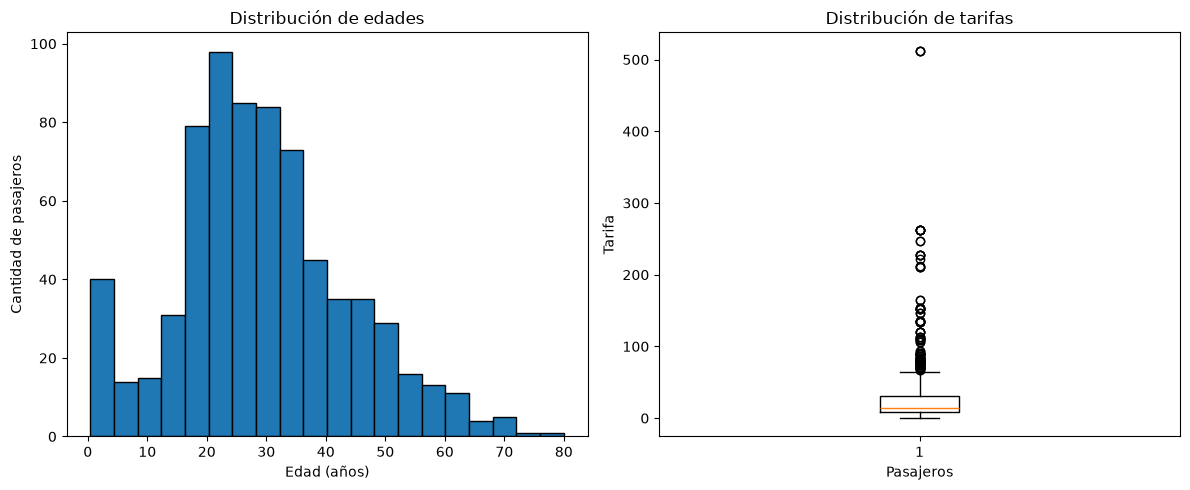

In [12]:
edades = df["age"].dropna()
tarifas = df["fare"].dropna()

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].hist(edades, bins=20, edgecolor="black")
ejes[0].set_title("Distribución de edades")
ejes[0].set_xlabel("Edad (años)")
ejes[0].set_ylabel("Cantidad de pasajeros")

ejes[1].boxplot(tarifas)
ejes[1].set_title("Distribución de tarifas")
ejes[1].set_xlabel("Pasajeros")
ejes[1].set_ylabel("Tarifa")

plt.tight_layout()
plt.show()

### Ejercicio 16 — Informe por puerto y exportación

1. Crear una copia de `df` y completar los nulos de `embark_town` con `Sin dato`.
2. Elaborar una tabla por puerto con cantidad de pasajeros, tarifa promedio y porcentaje de supervivencia.
3. Representar el porcentaje de supervivencia por puerto con un gráfico de barras, con eje vertical de 0 a 100.
4. Guardar la tabla en `data/resumen_titanic_por_puerto.csv`, incluyendo el puerto como columna y sin exportar el índice.
5. Volver a leer el archivo y comprobar que conserva las mismas columnas y cantidad de filas.
6. Escribir una conclusión de dos o tres oraciones. Aclarar por qué esta comparación por sí sola no demuestra que el puerto haya causado una diferencia en supervivencia.

**Pista:** usar `.groupby()`, `.agg()`, `.reset_index()` y `.to_csv(index=False)`.

   embark_town  cantidad  tarifa_promedio  porcentaje_supervivencia
0    Cherbourg       168        59.954144                 55.357143
1   Queenstown        77        13.276030                 38.961039
2     Sin dato         2        80.000000                100.000000
3  Southampton       644        27.079812                 33.695652


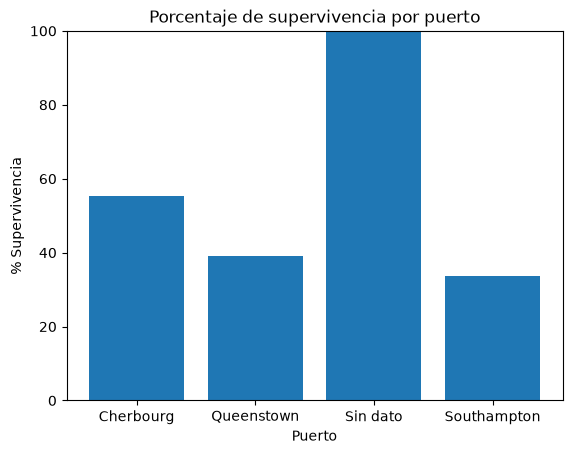

True
True


In [15]:
import os
os.makedirs("data", exist_ok=True)
df_puertos = df.copy()
df_puertos['embark_town'] = df_puertos['embark_town'].fillna('Sin dato')
 
resumen_puertos = df_puertos.groupby('embark_town').agg(
    cantidad=('survived', 'size'),
    tarifa_promedio=('fare', 'mean'),
    porcentaje_supervivencia=('survived', lambda x: x.mean() * 100)
).reset_index()
 
print(resumen_puertos)
 
plt.bar(resumen_puertos['embark_town'], resumen_puertos['porcentaje_supervivencia'])
plt.ylim(0, 100)
plt.title('Porcentaje de supervivencia por puerto')
plt.xlabel('Puerto')
plt.ylabel('% Supervivencia')
plt.show()
 
resumen_puertos.to_csv('data/resumen_titanic_por_puerto.csv', index=False)
 
verificacion = pd.read_csv('data/resumen_titanic_por_puerto.csv')
print(verificacion.shape == resumen_puertos.shape)
print(list(verificacion.columns) == list(resumen_puertos.columns))


### Ejercicio 17

Crear una clase `Sensor` con los atributos `nombre` y `mediciones`. Incorporar métodos para registrar una medición, calcular el promedio y devolver el estado del sensor.

In [16]:
class Sensor:
    def __init__(self, nombre, mediciones=None):
        self.nombre = nombre
        self.mediciones = mediciones if mediciones is not None else []

    def registrar_medicion(self, valor):
        self.mediciones.append(valor)

    def calcular_promedio(self):
        if not self.mediciones:
            return None
        return sum(self.mediciones) / len(self.mediciones)

    def obtener_estado(self):
        if not self.mediciones:
            return "sin mediciones"
        return "activo"



sensor = Sensor("Temperatura sala")
print(sensor.obtener_estado())     
print(sensor.calcular_promedio())   

sensor.registrar_medicion(21.5)
sensor.registrar_medicion(23.0)
sensor.registrar_medicion(22.1)

print(sensor.mediciones)           
print(sensor.calcular_promedio())  
print(sensor.obtener_estado())     

sin mediciones
None
[21.5, 23.0, 22.1]
22.2
activo
